In [370]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb

In [371]:
df_loan = pd.read_csv('/Users/sirawitjudjan/Documents/สมัครงาน/โปรเจคสมัครงาน/Credit risk analysis/Dataset&SQL/loans_full_schema_1XG.csv')
df_loan = df_loan.dropna()  # Drop rows with missing values


In [372]:
x_col_names = ['annual_income', 'debt_to_income', 'delinq_2y', 'num_collections_last_12m', 'num_historical_failed_to_pay','total_collection_amount_ever', 'num_cc_carrying_balance', 'account_never_delinq_percent', 'tax_liens', 'loan_amount', 'term', 'interest_rate', 'grade', 'total_credit_utilized']
y_col_name = 'loan_status'

In [373]:
from sklearn.model_selection import train_test_split
X = df_loan[x_col_names]
y = df_loan[y_col_name]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [374]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=442/103
)
model.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [375]:

y_prob = model.predict_proba(X_test_scaled)[:, 1]


threshold = 0.16

y_pred = (y_prob >= threshold).astype(int)

In [376]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.4679


In [377]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[33 55]
 [ 3 18]]
              precision    recall  f1-score   support

           0       0.92      0.38      0.53        88
           1       0.25      0.86      0.38        21

    accuracy                           0.47       109
   macro avg       0.58      0.62      0.46       109
weighted avg       0.79      0.47      0.50       109



In [378]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC =", auc)


ROC-AUC = 0.7083333333333333


## Feature Importance

In [379]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

In [380]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
11,interest_rate,0.163292
0,annual_income,0.127761
10,term,0.120058
5,total_collection_amount_ever,0.117921
1,debt_to_income,0.101324
13,total_credit_utilized,0.089595
9,loan_amount,0.081519
6,num_cc_carrying_balance,0.076371
7,account_never_delinq_percent,0.072232
2,delinq_2y,0.048223


### Finding from feature importance
A top3 importance feature that most contribute to our model are 1.interest rate, 2.annual income and 3.term . 

## SHAP Summary Plot

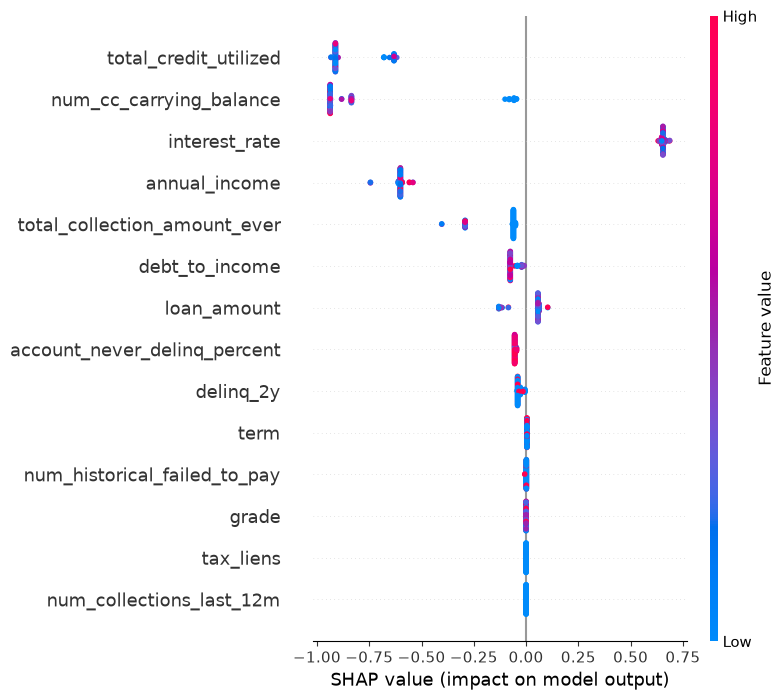

In [381]:
shap.summary_plot(
    shap_values,
    X_test
)

### Finding from SHAP summary plot
When we compare all feature SHAP values, there are four features that seem obvious significant. First, total_credit_utilized are mostly blue negative SHAP point show that a persom who use low amount of credit decreasing chance to loan default. Second, num_cc_carrying_balance which shows a range from red point to blue point in the left side indicates that any person who has credit card decreasing a chance to loan default. Third, interest rate shows a range from red point to blue point in the right side shows that for any rate of interest trend to increase a probability of laon default, Lastly, annual_income which shows a range from red point to blue point in the left side indicates that in any range of income decreasing a chance to loan default.

## SHAP Dependence Plot

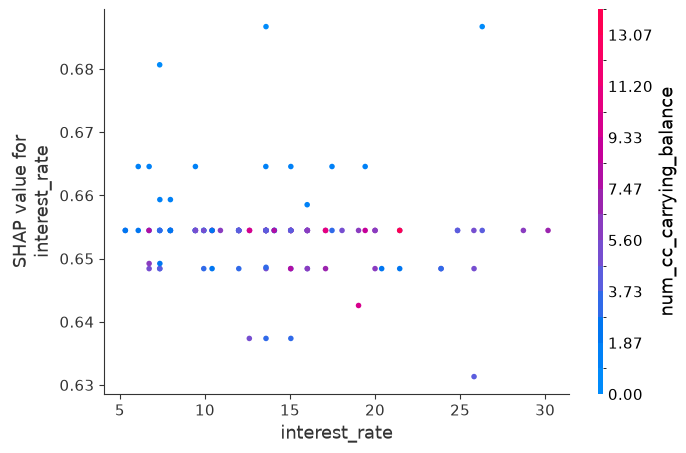

In [382]:
shap.dependence_plot(
    "interest_rate",
    shap_values,
    X_test
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


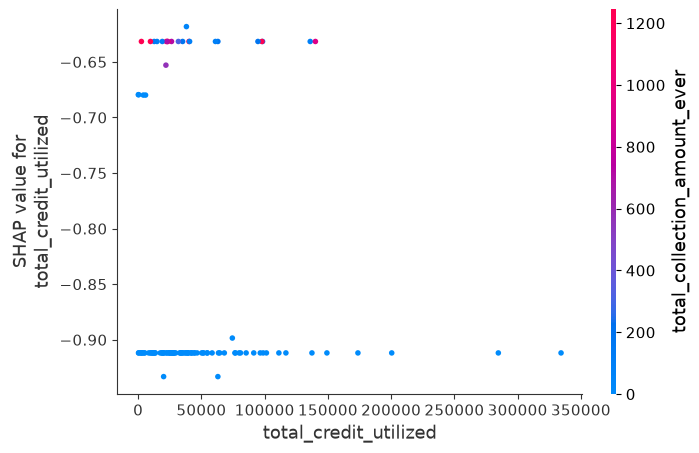

In [386]:
shap.dependence_plot(
    "total_credit_utilized",
    shap_values,
    X_test
)

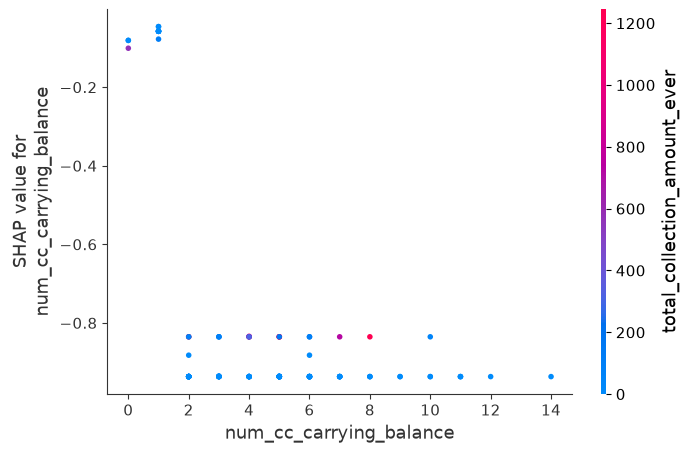

In [387]:
shap.dependence_plot(
    "num_cc_carrying_balance",
    shap_values,
    X_test
)

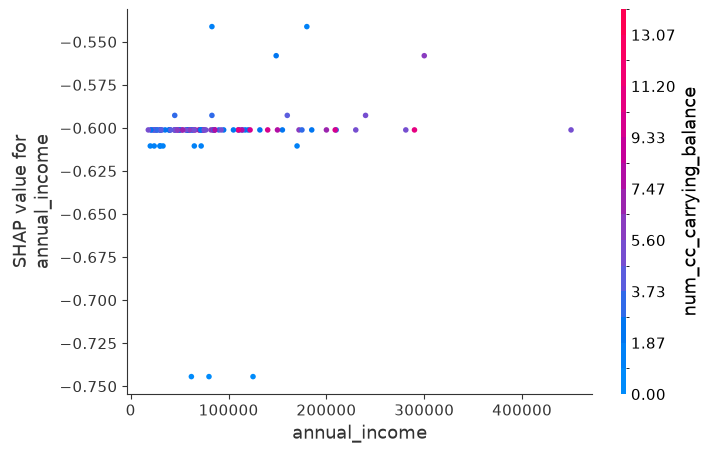

In [389]:
shap.dependence_plot(
    "annual_income",
    shap_values,
    X_test
)

### Finding from SHAP dependence plot
Elaboration on each features by using SHAP dependence plot, we finding more information on total_credit_utilized and num_cc_carrying_balance. 
* For total credit utilized Credit utilisation contributes to the prediction, but its effect is not purely linear. The model appears to distinguish different borrower profiles rather than applying a simple "higher utilisation equals higher risk" rule.Historical collection activity appears to strengthen the impact of credit utilisation, suggesting that borrowers with both high credit exposure and collection history deserve closer monitoring.
* Within this dataset, borrowers with more credit card accounts carrying balances generally received lower predicted default contributions from this feature. This finding is counterintuitive and may reflect other underlying borrower characteristics rather than a causal relationship.

## Business Insights
1. Interest rate feature is  most contribute predictive for XG boost model by increase a probability of loan default . However, this variable may was determined by lender from a historical credit before a loan contract was creating.
2. Total utilization contribute model prediction on negative side although it isn't linear relationship but it distinguish between two groups of borrower at two different level of prediction.
3. A higher historical collection amount of loan appears to impact a prediction from total utilization in less negative group of borrowers.
4. Normally, debt to income seems to be an important metric for loan default predictions but in result appears that this features less contribute to model prediction compared to with other features.
5. Annual income appears 2nd feature importance in XG boost model show that higher income decrease a default prediction.